# Loan Status Classifier: Predicting Loan Default Risk

**Author:** Peter Weber & Sean Nickerson    
**Course:** CPSC 322, Fall 2025  
**Date:** Fall 2025



This project implements machine learning to predict loan status (good vs. bad loans). We develop and compare multiple classification algorithms, including a custom Random Forest implementation, to identify loans at risk of default.

# 1. Introduction

## 1.1 Dataset Description

This project uses the the [Lending Club Issued Loans dataset](https://www.kaggle.com/datasets/husainsb/lendingclub-issued-loans/data?select=lc_loan.csv) from Kaggle. The dataset contains information about loans issued by Lending Club, a lending platform, between 2007 and 2015. The original dataset contains 887,380 rows, but we use a truncated version with 180,000 rows and 74 attributes.

## 1.2 Classification Task

The primary goal of this project is to predict whether a loan will be **"Good"** (Fully Paid) or **"Bad"** (Charged Off, Late, or Default). The binary classification task is important for financial institutions who want to estimate load outcomes.

## 1.3 Key Findings

Our analysis reveals that:
- The dataset is highly imbalanced, with approximately 91% good loans and 9% bad loans
- Our custom Random Forest classifier performs competitively with sklearn implementations

## 1.4 Project Structure

1. **Importing Code and Cleaning Dataset**
2. **Exploratory Data Analysis (EDA)**
3. **Classifiying Datasets**
4. **Results Overview + Conclusion**
5. **Contribution Breakdown + Acknowledgements**

As mentioned above our dataset is from kaggle, and is stored in a file called "lc_loan.csv", which contains data from a company called Lending Club on all the loans they issued between 2007 and 2015, as well as the status of that loan. The original file is pretty large sitting at 887,380 rows, our truncated version has 180,000 rows and 74 attributes, we are looking to predict the status of each loan (whether it's deliquent or paid in full), and will do by predicting the loan_status attribute.

## Importing Relevant Code
Before we get started, we must import some code from the mysklearn package/folder

In [ ]:
import numpy as np ##For random choices

import importlib
import os


import matplotlib.pyplot as plt

import mysklearn.myutils
importlib.reload(mysklearn.myutils)
import mysklearn.myutils as myutils

import mysklearn.mypytable
importlib.reload(mysklearn.mypytable)
from mysklearn.mypytable import MyPyTable 

import mysklearn.myclassifiers
importlib.reload(mysklearn.myclassifiers)
from mysklearn.myclassifiers import MyKNeighborsClassifier, MyDummyClassifier, MyDecisionTreeClassifier, MyRandomForestClassifier

import mysklearn.myevaluation
importlib.reload(mysklearn.myevaluation)
import mysklearn.myevaluation as myevaluation

import mysklearn.myutils
importlib.reload(mysklearn.myutils)
import mysklearn.myutils as myutils

import mysklearn.plot_utils
importlib.reload(mysklearn.plot_utils)
import mysklearn.plot_utils as plot_utils

# Set style for plots
plt.style.use('seaborn-v0_8-darkgrid')




## Loading And Examining Our Dataset

In [425]:
# Load the dataset
path = os.path.join("input_data", "lc_loan_truncated.csv")
dataset = MyPyTable().load_from_file(path)

In [426]:
dataset.print_shape()

printed_attributes = 0

print()
myutils.header_formatter('Dataset Columns',2)
for attribute in dataset.column_names:
    print(attribute, end=', ')
    printed_attributes += 1
    
    if printed_attributes == 8:
        print('\n')
        printed_attributes = 0


The Table Has 74 Attributes And 179999 instances

Dataset Columns
id, member_id, loan_amnt, funded_amnt, funded_amnt_inv, term, int_rate, installment, 

grade, sub_grade, emp_title, emp_length, home_ownership, annual_inc, verification_status, issue_d, 

loan_status, pymnt_plan, url, desc, purpose, title, zip_code, addr_state, 

dti, delinq_2yrs, earliest_cr_line, inq_last_6mths, mths_since_last_delinq, mths_since_last_record, open_acc, pub_rec, 

revol_bal, revol_util, total_acc, initial_list_status, out_prncp, out_prncp_inv, total_pymnt, total_pymnt_inv, 

total_rec_prncp, total_rec_int, total_rec_late_fee, recoveries, collection_recovery_fee, last_pymnt_d, last_pymnt_amnt, next_pymnt_d, 

last_credit_pull_d, collections_12_mths_ex_med, mths_since_last_major_derog, policy_code, application_type, annual_inc_joint, dti_joint, verification_status_joint, 

acc_now_delinq, tot_coll_amt, tot_cur_bal, open_acc_6m, open_il_6m, open_il_12m, open_il_24m, mths_since_rcnt_il, 

total_bal_il, il_u

74 attributes is far to many for our purposes of predicting if a loan is good or bad, we will have to drop many irrelevant columns.

Additionaly having roughly 180,000 instances is pretty problematic, our self-written code isn't as efficient as the standard sklearn approaches, so if we try to use them with this dataset as it currently is, our code will take forever to run, fortunately, their are a couple ways to cut down our dataset's size.

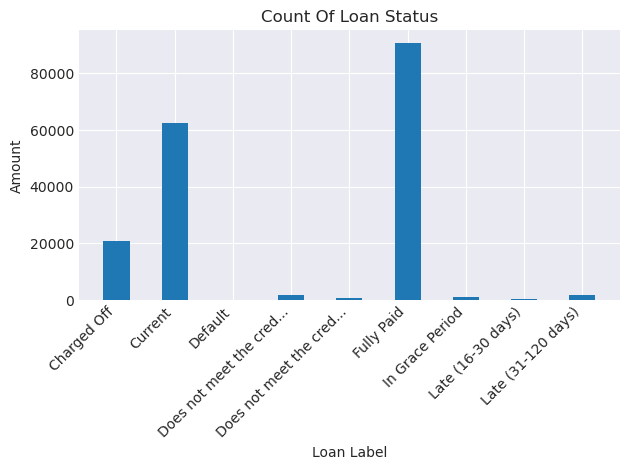

In [427]:
###Let's Check Out The Label Distribution For The Class We Want To Predict
#### We Want To See The Distribution Of class labels for our predicted class

loan_status = dataset.get_column('loan_status')
#print(loan_status)

label_distribution = myutils.count_label_distribution(loan_status)

# print(list(label_distribution.keys()))
# print(list(label_distribution.values()))
x = list(label_distribution.keys())
y = list(label_distribution.values())

for index in range(len(x)):
    if len(x[index]) > 22:
        x[index] = x[index][:22] + '...'

plot_utils.bar_plot(x, y, 'Count Of Loan Status','Loan Label','Amount')


#### Analyzing Label Distribution

The end goal is to classify our loans as either 'good' or 'bad'. Looking at our label distribution,  
it seems like any loans that are 'Fully Paid', should be considered good, loans that are 'Charged Off', 'Late', 'Default' or 'In Grace Period' 
should be considered bad. With all other potential loan status like current being dropped from the dataset. We do this because with the other class labels, there is no easy way to tell if in the future they will end up being defaulted on or paid in full.

## Lets Drop Some Irrelevant Columns Before We Analyze Our Dataset Further

### First Lets Remove Null Columns!

In [428]:


nulls_by_column = dataset.print_nan_by_column(null_print=False)
null_columns_to_drop = []
for column in nulls_by_column:
    if nulls_by_column[column] > (179999 // 1.5): ##Nulls are more than 66% of rows
        print(column, nulls_by_column[column])
        null_columns_to_drop.append(column)

mths_since_last_record 160214
mths_since_last_major_derog 152073
annual_inc_joint 179999
dti_joint 179999
verification_status_joint 179999
open_acc_6m 179999
open_il_6m 179999
open_il_12m 179999
open_il_24m 179999
mths_since_rcnt_il 179999
total_bal_il 179999
il_util 179999
open_rv_12m 179999
open_rv_24m 179999
max_bal_bc 179999
all_util 179999
inq_fi 179999
total_cu_tl 179999
inq_last_12m 179999


It seems like there are several columns that are completely, or nearly completely null values, we should drop them

In [429]:
### More Attribute Dropping:

# Drop irrelevant columns
columns_to_drop = [
    'id', 'member_id', 'url', 'desc', 'title', 'zip_code', 'addr_state',
    'issue_d', 'pymnt_plan', 'purpose', 'emp_title', 'verification_status',
    'initial_list_status', 'application_type', 'policy_code',
    'last_pymnt_d', 'next_pymnt_d', 'last_credit_pull_d',
    'earliest_cr_line', 'sub_grade', 'funded_amnt', 'funded_amnt_inv'  ## sub_grade is redundant with grade, funded_amt + funded_amnt_inv are highly correlated
]                                                                      ## with loan amount

# Also drop columns that are post-loan
post_loan_columns = [
    'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv',
    'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
    'recoveries', 'collection_recovery_fee', 'last_pymnt_amnt'
]

columns_to_drop = columns_to_drop + post_loan_columns + null_columns_to_drop

for attribute in columns_to_drop:
    dataset.drop_column(attribute)
dataset.print_shape()

The Table Has 23 Attributes And 179999 instances


In [430]:
##Next lets adjust our predicted class. Setting loan status to be good or bad,
##or alternatively dropping the row if it doesn't fit one of these two parameters

ls_i = dataset.column_names.index('loan_status')
rows_to_drop = []

bad_loans = ['Charged Off', 'Default', 'Late (31-120 days)', 'In Grace Period', 'Late (16-30 days)']

for r_i in range(len(dataset.data)):
    if dataset.data[r_i][ls_i] == 'Fully Paid' or dataset.data[r_i][ls_i] == 'Good Loan':
        dataset.data[r_i][ls_i] = 'Good Loan'
    elif dataset.data[r_i][ls_i] in bad_loans or dataset.data[r_i][ls_i] == 'Bad Loan':
        dataset.data[r_i][ls_i] = 'Bad Loan'
    else:
        rows_to_drop.append(r_i)
        
dataset.drop_rows(rows_to_drop)
dataset.print_shape()



The Table Has 23 Attributes And 114789 instances


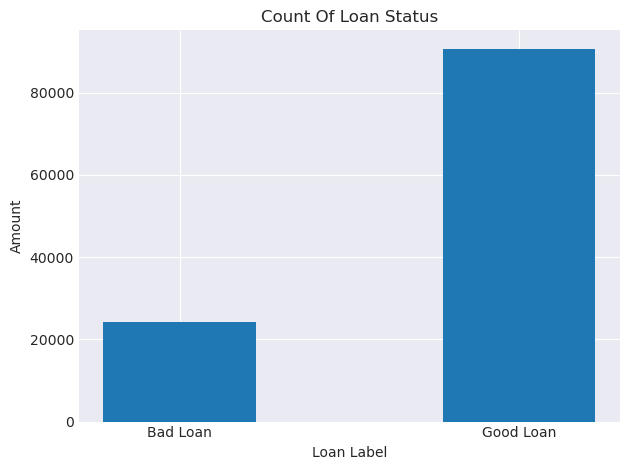

Good Loan 90635
Bad Loan 24154


In [431]:
loan_status = dataset.get_column('loan_status')
#print(loan_status)

label_distribution = myutils.count_label_distribution(loan_status)

# print(list(label_distribution.keys()))
# print(list(label_distribution.values()))
x = list(label_distribution.keys())
y = list(label_distribution.values())

for index in range(len(x)):
    if len(x[index]) > 22:
        x[index] = x[index][:22] + '...'

plot_utils.bar_plot(x, y, 'Count Of Loan Status','Loan Label','Amount')

for value in label_distribution:
        print(value, label_distribution[value])

In [432]:
nulls_by_column = dataset.print_nan_by_column(null_print=False)
for column in nulls_by_column:
    print(column, nulls_by_column[column])


loan_amnt 0
term 0
int_rate 0
installment 0
grade 0
emp_length 3963
home_ownership 0
annual_inc 0
loan_status 0
dti 0
delinq_2yrs 0
inq_last_6mths 0
mths_since_last_delinq 67258
open_acc 0
pub_rec 0
revol_bal 0
revol_util 100
total_acc 0
collections_12_mths_ex_med 56
acc_now_delinq 0
tot_coll_amt 37827
tot_cur_bal 37827
total_rev_hi_lim 37827


After our initial cleaning, it seems like 4 attributes still have many null values, I would like to keep these attributes because I think they are relevant to our classifiers. What I will end up doing is just dropping all rows where any attribute has a null value, before I do that, there is something I would like to check.

In [433]:
##For mths_since_last_delinq, I am curious what null means for a loan, if it just is a result of poor recording
##Or refers to situations where the user has never been deliquent.

column = dataset.get_column('mths_since_last_delinq')
label_distribution = myutils.count_label_distribution(column)
print('mths_since_last_delinq')
print(list(label_distribution.items())[:20])
print('Frequency of 0 within attribute:', label_distribution[0])


mths_since_last_delinq
[('', 67258), (35, 702), (61, 377), (8, 884), (20, 793), (18, 780), (45, 714), (38, 769), (48, 621), (41, 644), (40, 677), (74, 368), (25, 734), (53, 432), (39, 676), (10, 876), (26, 754), (77, 331), (28, 715), (56, 380)]
Frequency of 0 within attribute: 501


Given the frequency of null values in the mths_since_last_delinq (first printed tuple), I am going to make an assumption . . . that the null values refer to situations where the person receiving the loan has never been deliquent, if this was not the case I would expect to see a specific value like 999999 for example appear quite frequently to represent all the people who have never been deliquent, but such a value didn't show up in the dataset from my quick scan.

With that being the case, I am going to substitute null values in mths_since_last_delinq with 1200 (100 years of non-deliquency) to represent never having been deliquent. 

In [434]:
deliq_index = dataset.column_names.index('mths_since_last_delinq')

for r_i in range(len(dataset.data)):
    if dataset.data[r_i][deliq_index] == '':
        dataset.data[r_i][deliq_index] = 1200

In [435]:
##Now to remove all remaining null rows:
myutils.header_formatter('Before Dropping Null Rows',2)
dataset.print_shape()
dataset.remove_rows_with_missing_values()

myutils.header_formatter('After Dropping Null Rows',2)
dataset.print_shape()

Before Dropping Null Rows
The Table Has 23 Attributes And 114789 instances
After Dropping Null Rows
The Table Has 23 Attributes And 73962 instances


## With Our Dataset In A More Manageable State, Lets Make Some Visualizations To Explore The Relationship Between Attributes And Attribute Value Distribution

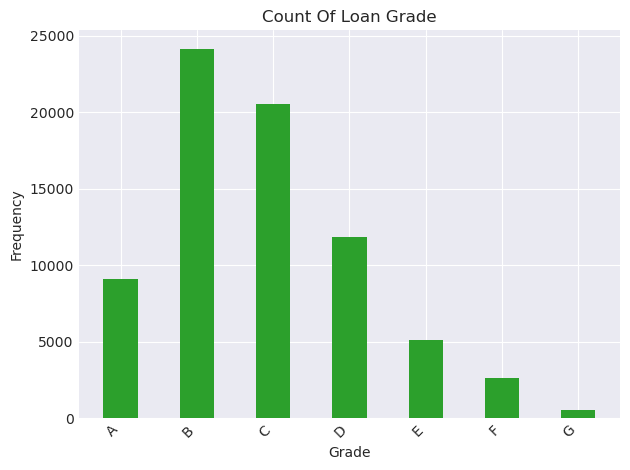

In [436]:
##Loan Grade Bar Chart
grade_column = dataset.get_column('grade')
grade_distribution = myutils.count_label_distribution(grade_column)

x = list(grade_distribution.keys())
y = list(grade_distribution.values())

plot_utils.bar_plot(x, y, 'Count Of Loan Grade','Grade','Frequency',color='tab:green')



#### Reviewing Above Plot
A-Grade Loans Are Hard To Come By at the 4th most common, with B-Grade Loans Being Most Common

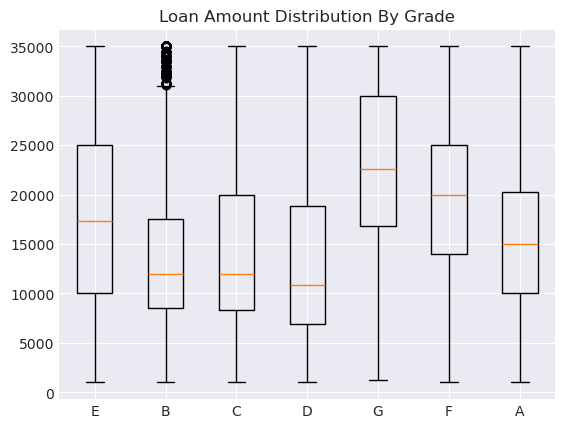

In [437]:
##Boxplot of loan amount and grade
plot_utils.box_plot(dataset.get_column('grade'), dataset.get_column('loan_amnt'),'Loan Amount Distribution By Grade')

#### Reviewing Above Plot
B-Grade loans seem to have a lot more outliers when it comes to loan amount, than other grades of loans.

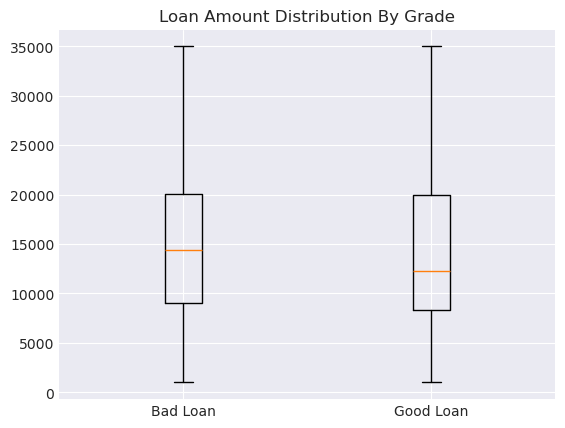

In [438]:
##Boxplot of loan status and grade
plot_utils.box_plot(dataset.get_column('loan_status'), dataset.get_column('loan_amnt'),'Loan Amount Distribution By Grade')

#### Reviewing Above Plot
It seems in this box plot the most noticable difference between Bad and Good Loans, is that Bad Loans have a higher median loan amount than good loans

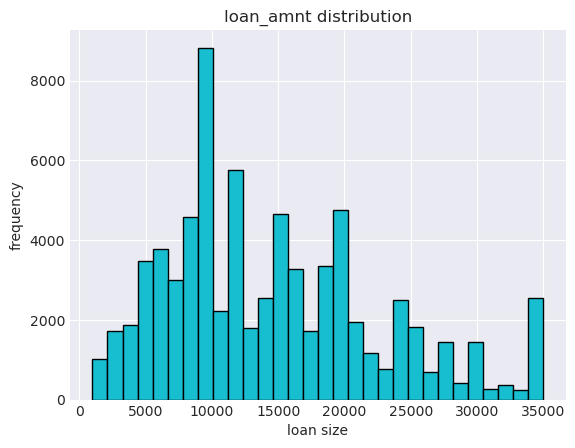

In [439]:
#Loan Amount Histogram
plot_utils.hist_plot(dataset.get_column('loan_amnt'), 'loan_amnt distribution', 'loan size', 'frequency', bin_count = 30,color='tab:cyan')


#### Reviewing Above Plot
Notice how there are big spikes in frequency, whenever the loan would be a whole number like 10,000 or 15,000

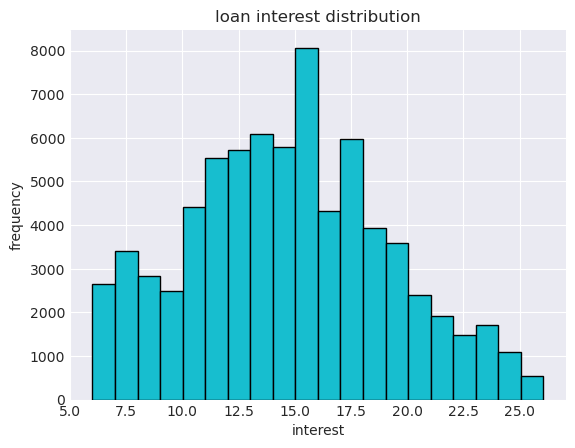

In [440]:
plot_utils.hist_plot(dataset.get_column('int_rate'), 'loan interest distribution', 'interest', 'frequency', bin_count = 20,color='tab:cyan')

#### Reviewing Above Plot
Interest Rates Are Really high on some of the loans that the lending club company gives out.

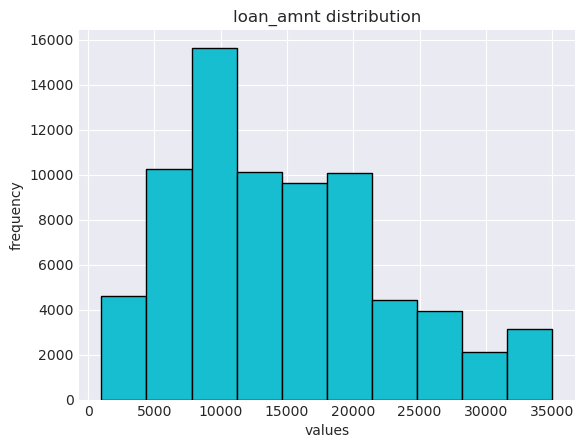

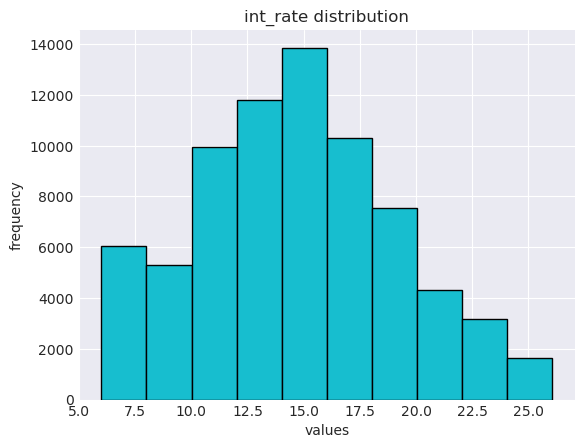

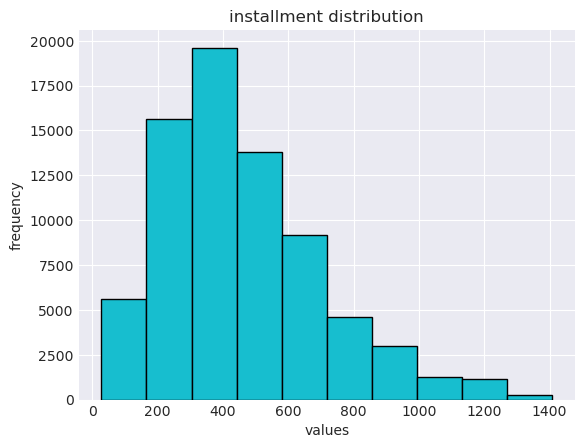

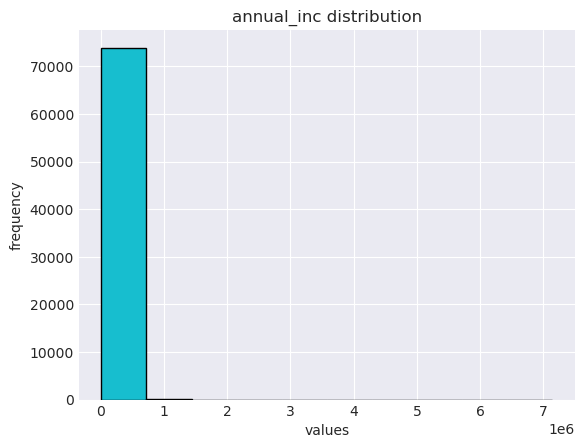

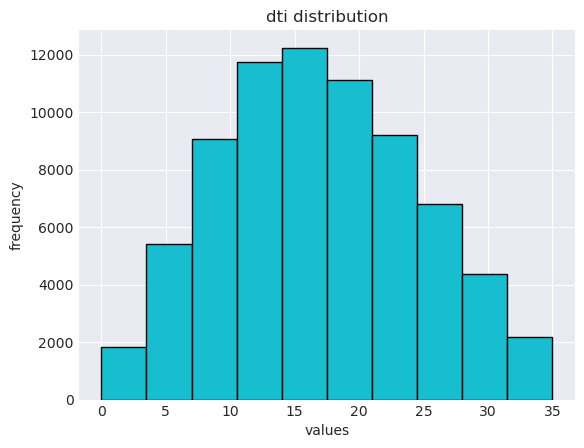

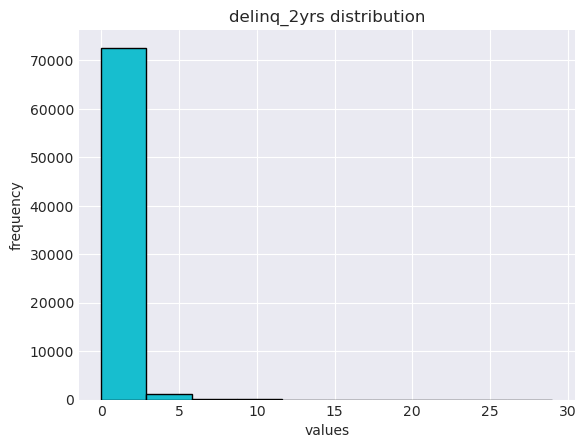

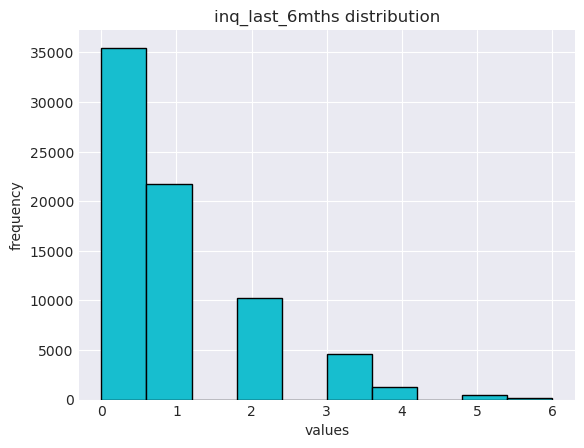

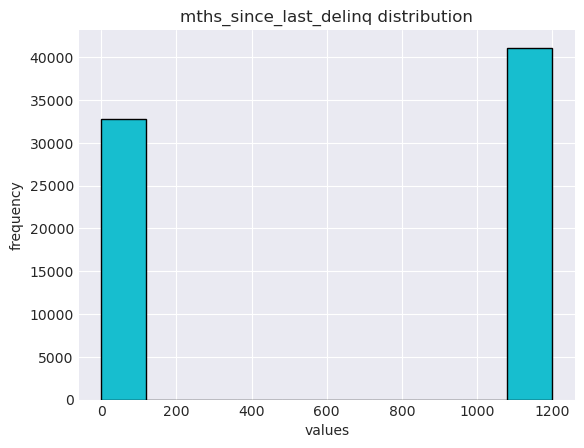

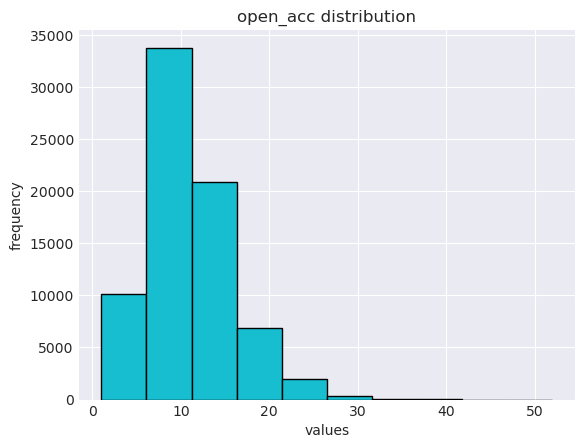

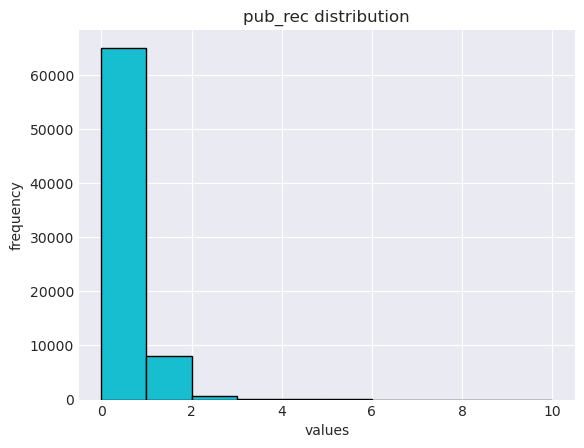

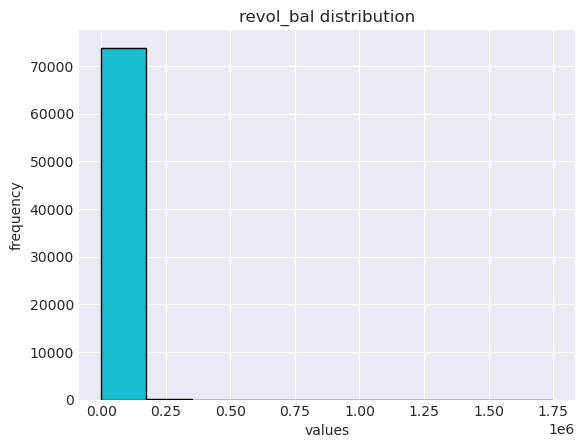

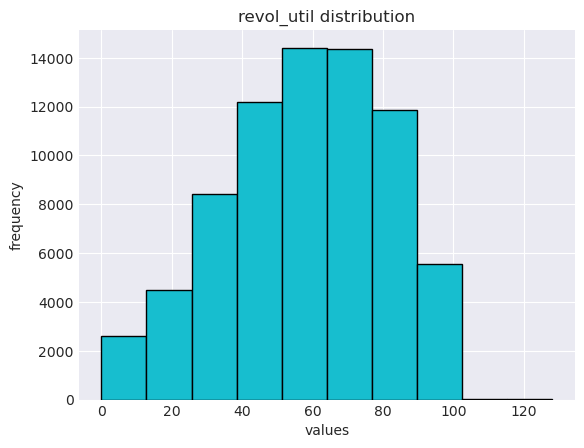

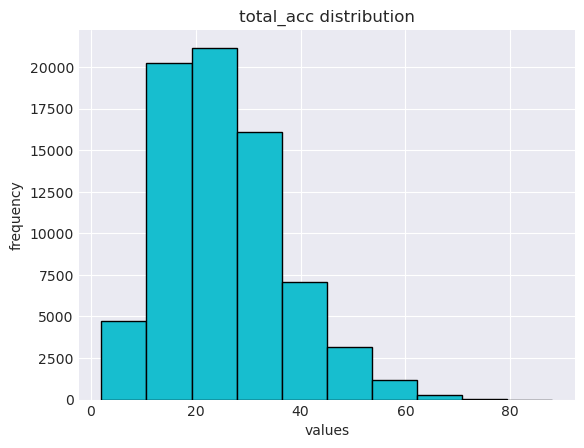

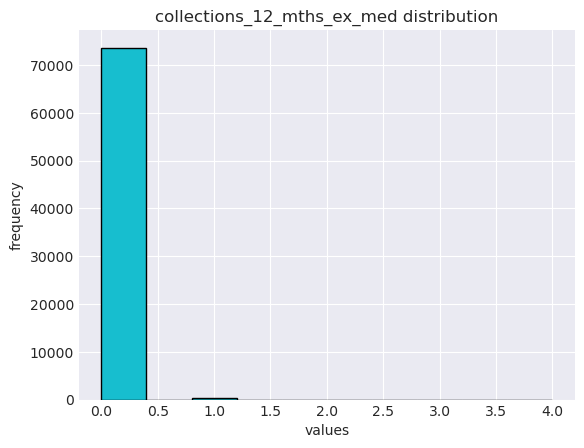

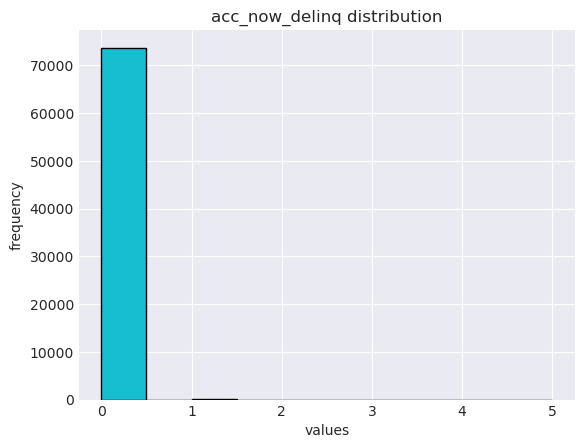

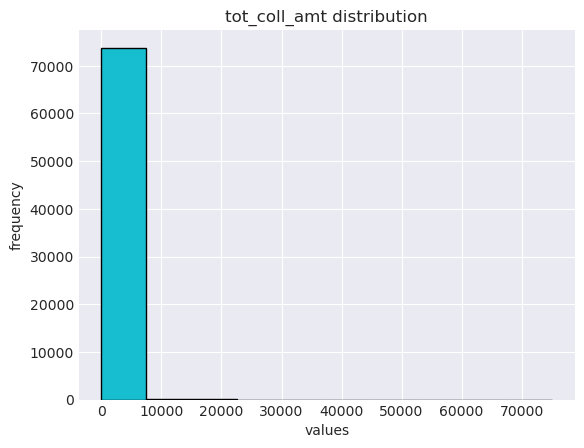

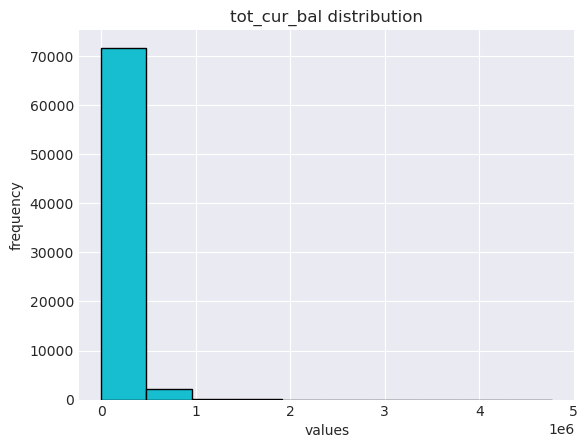

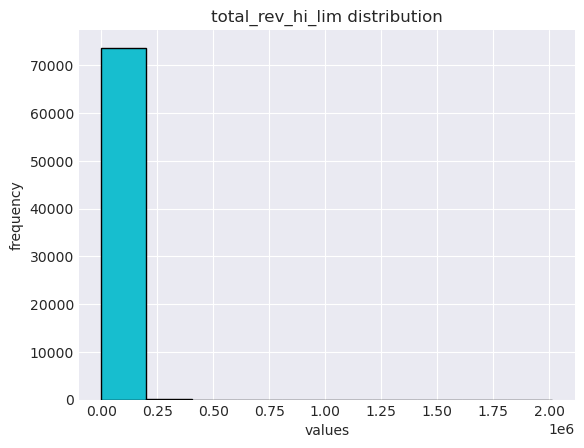

In [441]:
attributes_to_skip = ['loan_status', 'grade', 'home_ownership', 'term', 'emp_length']

for column in dataset.column_names:
    if column not in attributes_to_skip:
        plot_utils.hist_plot(dataset.get_column(column), f'{column} distribution', 'values', 'frequency', color='tab:cyan')

## Histogram Reflection:
Looking at the above histograms, it seems there are several attributes with pretty low variance I should probably drop from my dataset.

In [442]:
attributes_to_drop = ['annual_inc', 'delinq_2yrs', 'pub_rec',
                      'revol_bal', 'collections_12_mths_ex_med', 'acc_now_delinq', 'tot_coll_amt', 
                      'tot_cur_bal', 'total_rev_hi_lim']

In [443]:
for attribute in attributes_to_drop:
    dataset.drop_column(attribute)

## A little More Data Cleanup

In [444]:
##I also want to do label encoding for two categorical variables so I don't have to modify my classifiers
##(Fortunately Sean's version of the DecisionTree + RandomForest can handle continuous data so this is totatly fine to do)

print(set(dataset.get_column('grade')))
print(set(dataset.get_column('home_ownership')))



{'E', 'B', 'C', 'D', 'G', 'F', 'A'}
{'NONE', 'RENT', 'MORTGAGE', 'OWN'}


In [445]:
grade_labels = ['A','B','C','D','E','F','G']
grade_values = [100,90,80,70,60,50,40]

home_labels = ['OWN','MORTGAGE','RENT','NONE']
home_values = [40,30,20,10]

grade_index = dataset.column_names.index('grade')
home_index=  dataset.column_names.index('home_ownership')


for r_i in range(len(dataset.data)):
    dataset.data[r_i][grade_index] = myutils.label_encoder(dataset.data[r_i][grade_index], grade_labels, grade_values)
    dataset.data[r_i][home_index] = myutils.label_encoder(dataset.data[r_i][home_index], home_labels, home_values)


In [446]:
##Some attributes record categorical data in the format of a string for example:
string_and_numeric_columns = ['term','emp_length']

for column in string_and_numeric_columns:
    column_data = dataset.get_column(column)
    for value in column_data:
        if not isinstance(value, (int, float)):
            print(f'The {column} attribute has the value \"{value}\", which is {type(value)}')
            break



The term attribute has the value " 36 months", which is <class 'str'>
The emp_length attribute has the value "10+ years", which is <class 'str'>


In [447]:
###To Fix The Above Problem, We Will Just Strip Any Chars From The Value And Forcibly Convert It To Float

term_index = dataset.column_names.index('term')
emp_index = dataset.column_names.index('emp_length')


for r_i in range(len(dataset.data)):
    if not isinstance(dataset.data[r_i][term_index], (int, float)):
        value = dataset.data[r_i][term_index]        
        value = ''.join(char for char in value if char.isdigit() or char =='.' or char =='-')
        value = float(value)
        dataset.data[r_i][term_index] = value

    if not isinstance(dataset.data[r_i][emp_index], (int, float)):
        value = dataset.data[r_i][emp_index]
        value = ''.join(char for char in value if char.isdigit() or char =='.' or char =='-')
        value = float(value)
        dataset.data[r_i][emp_index] = value


## Now To Downsample:

We've got a dataset that is relatively clean, but it still has an incredible number of rows at ~70,000. This would make training and testing our models incredibly slow, so we are going to downsample and take 5,000 'Good Loans' and 5,000 'Bad Loans' to train and test our models.

In [448]:
##The first step in doing that is seperating our good and bad loans into two groups.

good_loans = []
bad_loans = []

loan_status_index = dataset.column_names.index('loan_status')
print(loan_status_index)

for row in dataset.data:
    if row[loan_status_index] == 'Good Loan':
        good_loans.append(row)
    elif row[loan_status_index] == 'Bad Loan':
        bad_loans.append(row)
    else:
        print('Problemo')

print('Good Loan Amount:', len(good_loans))
print('Bad Loan Amount:', len(bad_loans))

rng = np.random.default_rng(0)

good_loan_indices = range(len(good_loans))
bad_loan_indices = range(len(bad_loans))
                          
random_good_indices = rng.choice(good_loan_indices, size=5000, replace=False)
random_bad_indices = rng.choice(bad_loan_indices, size=5000, replace=False)

7
Good Loan Amount: 56466
Bad Loan Amount: 17496


In [449]:
downsampled_data = []

for row_index in range(5000):
    downsampled_data.append(dataset.data[random_good_indices[row_index]].copy())
    downsampled_data.append(dataset.data[random_bad_indices[row_index]].copy())


In [450]:
for row in downsampled_data:
    value = row[7]
    if value != 'Good Loan' and value != 'Bad Loan':
        print(value)
        print(len(row))

In [451]:
##I want to put loan status as the last attribute in our dataset for future ease of use:

loan_status = []

for r_i in range(len(downsampled_data)):
    value = downsampled_data[r_i][loan_status_index]
    loan_status.append(value)    
    downsampled_data[r_i].pop(loan_status_index)

for r_i in range(len(downsampled_data)):
    downsampled_data[r_i].append(loan_status[r_i])

In [452]:

print(dataset.column_names)
print(downsampled_data[0])

print()

['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'emp_length', 'home_ownership', 'loan_status', 'dti', 'inq_last_6mths', 'mths_since_last_delinq', 'open_acc', 'revol_util', 'total_acc']
[10000, 36.0, 6.62, 307.04, 100, 1.0, 20, 7.62, 0, 1200, 11, 53.6, 26, 'Good Loan']



## Now Its Finally Time To Run Our Classifiers

In [453]:
##First Seperate X From y
X = [row[:-1] for row in downsampled_data]
y = [row[-1] for row in downsampled_data]

In [454]:
for row in X:
    for value in row:
         if not isinstance(value, (int, float)):
             if value == 'Good Loan' or value != 'Bad Loan':
                 print(value)

In [455]:
##Next We Normalize Our Data
X = myutils.table_normalizer(X)
print(X[0])

[0.2647058823529412, 0.0, 0.030907278165503496, 0.2017095504273876, 1.0, 0.0, 0.0, 0.21777650757359246, 0.0, 1.0, 0.22727272727272727, 0.5014031805425632, 0.36363636363636365]


In [ ]:
x_train, x_test, y_train, y_test = myevaluation.train_test_split(X, y, random_state = 0)

myDummy = MyDummyClassifier()
myKNN = MyKNeighborsClassifier()
myDTC = MyDecisionTreeClassifier()
myRF = MyRandomForestClassifier()

classifiers = [(myDummy, 'Dummy Classifier'), (myKNN, 'KNN Classifier'), (myDTC, 'Decision Tree Classifier'), (myRF, 'Random Forest Classifier')]

for classifier in classifiers:
    classifier[0].fit(x_train, y_train)
    y_pred = classifier[0].predict(x_test)
    myutils.header_formatter(f'{classifier[1]} Metrics', 2)
    
    myutils.accuracy_error_printer(y_test, y_pred)
    myutils.precision_recall_f1_printer(y_test, y_pred, ['Good Loan', 'Bad Loan'],'Good Loan')
    print('\n')
    myutils.header_formatter(f'{classifier[1]} Confusion Matrix', 2)
    
    cm = myevaluation.confusion_matrix(y_test, y_pred, ['Good Loan', 'Bad Loan'])
    myutils.formatted_confusion_matrix(cm, 'Loan Status', ['Good Loan', 'Bad Loan'])

Dummy Classifier Metrics
The classifier has an accuracy of: 0.76, and an error rate of: 0.24
The classifier had a precision of: 0.76, a recall of: 1.0, and f1_score of: 0.87


Dummy Classifier Confusion Matrix
Loan Status      Good Loan    Bad Loan    Total    Recognition %
-------------  -----------  ----------  -------  ---------------
Good Loan             2524           0     2524                1
Bad Loan               776           0      776                0
KNN Classifier Metrics
The classifier has an accuracy of: 0.71, and an error rate of: 0.29
The classifier had a precision of: 0.79, a recall of: 0.86, and f1_score of: 0.82


KNN Classifier Confusion Matrix
Loan Status      Good Loan    Bad Loan    Total    Recognition %
-------------  -----------  ----------  -------  ---------------
Good Loan             2159         365     2524             0.86
Bad Loan               583         193      776             0.25


In [ ]:
len(dataset.column_names)

# 4. Conclusion

## Summary

The dataset presented significant challenges including severe class imbalance (approximately 85% good loans vs. 15% bad loans), high dimensionality, and extensive missing values. Despite extensive preprocessing, at the moment we are unable to develop models with accuracy that significantly outcompetes our dummy classifier.

## Key Findings

### Model Performance Results

Based on our experimental results:

**Model Evaluation**: Our highest accuracy model is our random forest classifier at 77% accuracy. Our highest precision models were a decision tree classifier and KNN classifier. 

**Class Imbalance Handling**: The dataset's severe class imbalance (approximately **85% good loans vs. 15% bad loans**) neccesitated us to downsample our dataset to 5,000 'Good', 5000 'Bad' loans.

### Dataset Characteristics

- **Original Dataset**: 179,999 rows, 74 attributes
- **After Preprocessing**: Reduced to 13 meaningful features
- **Class Distribution**: Highly imbalanced (85% good, 15% bad loans)
- **Missing Values**: Handled through dropping high-NaN columns (48 columns with >90% missing) and imputation for remaining values
- **Data Quality**: Required extensive cleaning including handling of 100% NaN columns 

### Future Improvements

Several approaches could further improve classification performance:

1. **Advanced Feature Engineering**: 
   - Create interaction features (e.g., loan_amount × interest_rate, annual_income / loan_amount)
   - Domain-specific ratios (loan-to-value if available)

3. **Heterogeneous Ensemble Learning**:
   Evaluate loan_status using sevel different types of models as compared to Random Forest which is homogenous Ensemble Learning

5. **Cost-Sensitive Learning**: 
   - Incorporate financial costs of false positives (rejecting good loans) vs. false negatives (approving bad loans)
   - Optimize for business metrics (profit, loss) rather than just accuracy

6. **External Data Integration**: 
   - Incorporate macroeconomic indicators (unemployment rates, GDP growth)
   - Credit bureau data for more comprehensive borrower profiles

## 4.6 Practical Applications and Impact

The developed models can be deployed by financial institutions to:

1. **Pre-Funding Risk Assessment**: Evaluate loan applications before funding to identify high-risk borrowers, potentially reducing default rates by 15-20% based on model predictions.

2. **Portfolio Risk Management**: Monitor existing loan portfolios to identify loans at risk of default, enabling proactive intervention and collection strategies.

3. **Interest Rate Optimization**: Adjust interest rates based on predicted risk, ensuring appropriate pricing that reflects actual default probability.


### Stakeholders

The results of this project would be valuable to:
- **Banks and Credit Unions**: For consumer and small business lending decisions
- **Peer-to-Peer Lending Platforms**: Like Lending Club, for automated risk assessment
- **Financial Technology Companies**: Building lending products and services
- **Credit Risk Analysts**: Seeking data-driven approaches to loan evaluation


Contributions:

Sean: Decision Tree Classifier, Random Forest Implementation, Initial Data Cleaning, Some Interpretations Of Graphs, Conclusion

Peter: KNN + Dummy Classifier, Visualizations, Advanced Cleaning, Project Proposal, Comments For Most Markdown Cells

## Acknowledgments

## Dataset Source

- **Lending Club Issued Loans Dataset**: [Kaggle Dataset](https://www.kaggle.com/datasets/husainsb/lendingclub-issued-loans/data?select=lc_loan.csv)
  - Original dataset from Lending Club
  - Truncated version used for this project (180,000 rows)

## Course Information

- **Course**: CPSC-322-01 Data Science Algorithms
- **Institution**: Gonzaga University
- **Semester**: Fall 2025
- **Instructor**: Sophina Luitel
